# `AA Workshop 8` — Coding Challenge

Complete the tasks below to practice implementing classification modeling from `W8_Classification_Advanced.ipynb`.

Guidelines:
- Work in order. Run each cell after editing with Shift+Enter.
- Keep answers short; focus on making things work.
- If a step fails, read the error and fix it.

By the end you will have exercised:
- implementing classification models, including logistic regression, Naive Bayes, and SVMs
- evaluating and selecting the preferred model

## Task 1 - Predicting Penguin Species

Let's apply our classification skills in a multi-class setting. The Palmer penguins dataset contains information on three penguin species in the islands of the Palmer Archipelago, Antarctica. More information is available [here](https://archive.ics.uci.edu/dataset/690/palmer+penguins-3). When working on this task, keep in mind that this dataset is quite small (n=333 excluding observations missing data). You can load the data via seaborn using `sns.load_dataset("penguins").dropna()`. Train classifiers for the penguin species based on the two features `bill_length_mm` and `flipper_length_mm`. Specifically, evaluate the performance of a logistic regression, Gaussian Naive Bayes, and SVM classifier with linear kernel, polynomial kernel (3 degrees), and RBF kernel. Report the performance of your selected model.

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

In [17]:
data = sns.load_dataset("penguins").dropna()
data['species'] = data['species'].astype('str')
data['island'] = data['island'].astype('str')
data['sex'] = data['sex'].astype('str')
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [18]:
features = ["bill_length_mm", "flipper_length_mm"]

X = data[features].values
Y = data['species'].values

X_train, X_, Y_train, Y_ = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)
X_val, X_test, Y_val, Y_test = train_test_split(X_, Y_, test_size=0.5, random_state=42, stratify=Y_)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [24]:
model_types = {
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=200),
    "SVC_linear": SVC(kernel='linear'),
    "SVC_poly": SVC(kernel='poly', degree=3),
    "SVC_rbf": SVC(kernel='rbf'),
}

C = [0.01, 0.1, 1, 10, 100]

rows = []
for name, base_model in model_types.items():
    for c in C:
        model = clone(base_model)                      # avoid reusing the same fitted instance
        if 'C' in model.get_params().keys():
            model.set_params(C=c)
        model.fit(X_train_scaled, Y_train)             # train only on train set
        train_accuracy = model.score(X_train_scaled, Y_train)
        val_accuracy = model.score(X_val_scaled, Y_val)
        rows.append({
            "model": name,
            "C": c if 'C' in model.get_params().keys() else None,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy
        })
        # print(f"{name} (C={rows[-1]['C']}): Train={train_accuracy:.4f}, Val={val_accuracy:.4f}")
        if 'C' not in model.get_params().keys():
            break

results_df = pd.DataFrame(rows)
display(results_df.sort_values(['model','C'], na_position='first'))
print("\nTop 3 models by validation accuracy:")
display(results_df.sort_values(['val_accuracy'], na_position='first', ascending=False).head(3))

,model,C,train_accuracy,val_accuracy
0,GaussianNB,NaN,0.948498,0.94
1,LogisticRegression,0.01,0.845494,0.82
2,LogisticRegression,0.10,0.948498,0.94
3,LogisticRegression,1.00,0.957082,0.94
4,LogisticRegression,10.00,0.957082,0.96
5,LogisticRegression,100.00,0.952790,0.96
6,SVC_linear,0.01,0.841202,0.82
7,SVC_linear,0.10,0.948498,0.94
8,SVC_linear,1.00,0.948498,0.94
9,SVC_linear,10.00,0.952790,0.96



Top 3 models by validation accuracy:


,model,C,train_accuracy,val_accuracy
4,LogisticRegression,10.0,0.957082,0.96
19,SVC_rbf,10.0,0.961373,0.96
10,SVC_linear,100.0,0.961373,0.96


In [25]:
best_model = LogisticRegression(C=10, max_iter=200)
best_model.fit(X_train_scaled, Y_train)
test_accuracy = best_model.score(X_test_scaled, Y_test)
print(f"Test accuracy of the best model: {test_accuracy:.4f}")

Test accuracy of the best model: 0.9800


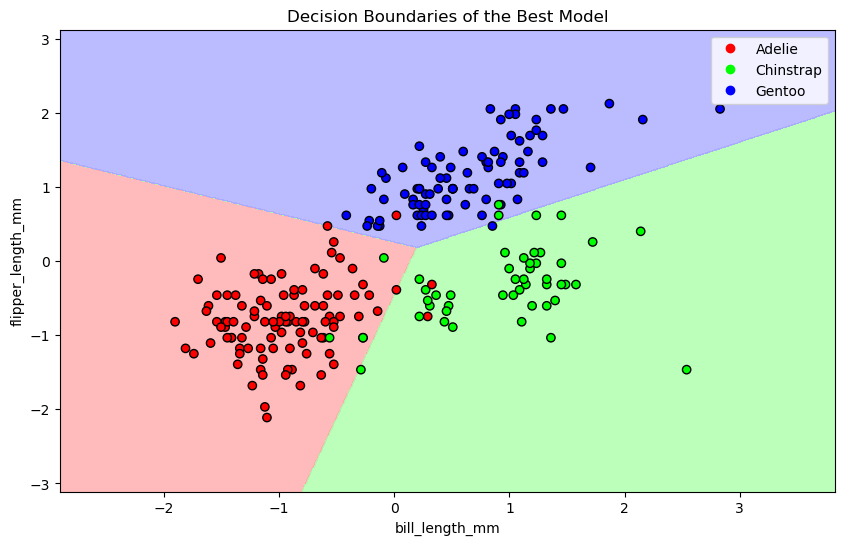

In [36]:
def plot_decision_boundaries(X, Y, model, title):
    X = np.asarray(X, dtype=float)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    raw_Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    if hasattr(model, "classes_"):
        class_to_int = {lab: i for i, lab in enumerate(model.classes_)}
    else:
        class_to_int = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
    Z = np.array([class_to_int[z] for z in raw_Z], dtype=float).reshape(xx.shape)
    Y_numeric = np.array([class_to_int[y] for y in Y])
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8,
                 cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=Y_numeric,
                          cmap=ListedColormap(['#FF0000', '#00FF00', '#0000FF']), edgecolor='k')
    plt.title(title)
    plt.xlabel(features[0] if 'features' in globals() else 'feat1')
    plt.ylabel(features[1] if 'features' in globals() else 'feat2')
    labels = list(class_to_int.keys())
    plt.legend(handles=scatter.legend_elements()[0], labels=labels)
    plt.show()

plot_decision_boundaries(X_train_scaled, Y_train, best_model, "Decision Boundaries of the Best Model")


---